In [1]:
import os
# M1 Mac segfault önlemi — torch import'tan ÖNCE set edilmeli
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import yfinance as yf
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Threading'i sınırla (M1 segfault fix)
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

import requests
from io import StringIO
from datetime import datetime
from typing import Optional

from fredapi import Fred

import warnings
warnings.filterwarnings('ignore')

DB_DIR = os.path.join(
    '/Users/aliemre2023/Desktop/apache_project/bist100_airflow/src/db'
)
DB_PATH = os.path.join(DB_DIR, 'bist.db')

def get_connection() -> sqlite3.Connection:
    os.makedirs(DB_DIR, exist_ok=True)
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    conn.execute("PRAGMA foreign_keys = ON")
    return conn

conn = get_connection()

In [2]:
SIRKET_CODE = "TUPRS"

In [3]:
df = yf.Ticker(f"{SIRKET_CODE}.IS").history(period="2000d")

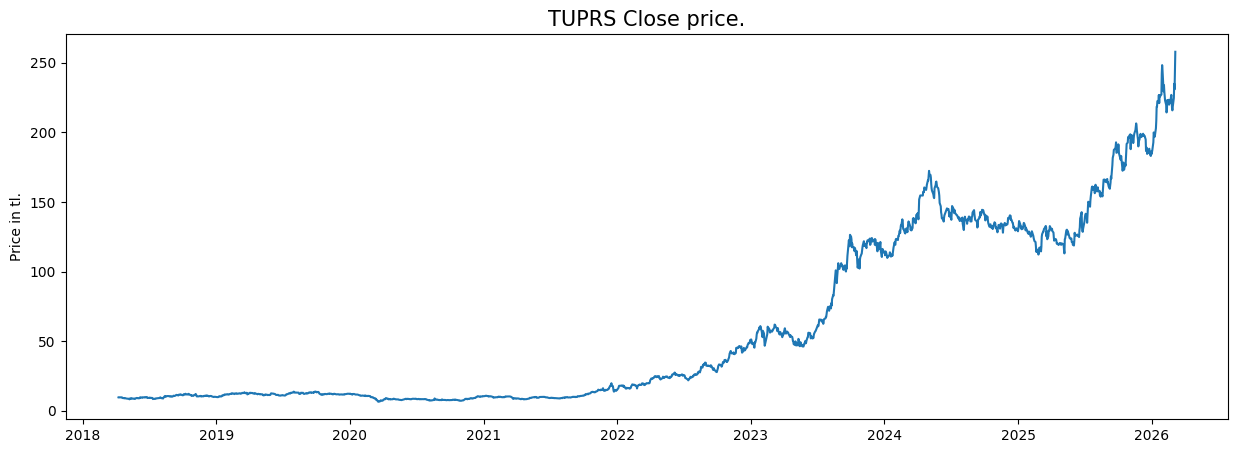

In [4]:
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title(f'{SIRKET_CODE} Close price.', fontsize=15)
plt.ylabel('Price in tl.')
plt.show()

In [5]:
df['day'] = df.index.day
df['month'] = df.index.month
df['year'] = df.index.year

df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,day,month,year
Date,,,,,,,,,,
2018-04-09 00:00:00+03:00,9.766998,9.775528,9.553746,9.587866,8024660,0.0,0.0,9,4,2018
2018-04-10 00:00:00+03:00,9.528155,9.562275,9.349022,9.511095,8179332,0.0,0.0,10,4,2018
2018-04-11 00:00:00+03:00,9.485505,9.690228,9.417264,9.621986,13348797,0.0,0.0,11,4,2018
2018-04-12 00:00:00+03:00,9.724347,9.724347,9.570804,9.673167,8802262,0.0,0.0,12,4,2018
2018-04-13 00:00:00+03:00,9.724348,9.724348,9.519625,9.621986,4248104,0.0,0.0,13,4,2018


In [6]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df[df["is_quarter_end"] == 1].head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,day,month,year,is_quarter_end
Date,,,,,,,,,,,
2018-06-01 00:00:00+03:00,9.033408,9.101649,8.896926,8.999288,9082283,0.0,0.0,1,6,2018,1
2018-06-04 00:00:00+03:00,9.127240,9.186951,8.828686,8.905457,24939761,0.0,0.0,4,6,2018,1
2018-06-05 00:00:00+03:00,8.913986,9.152830,8.905455,9.127239,8937880,0.0,0.0,5,6,2018,1
2018-06-06 00:00:00+03:00,9.127240,9.297843,8.956638,9.076059,8943949,0.0,0.0,6,6,2018,1
2018-06-07 00:00:00+03:00,9.110178,9.664638,9.067528,9.639047,16829092,0.0,0.0,7,6,2018,1


In [7]:
SERIES_CONFIG = {
    # ── Döviz Kurları ──────────────────────────────────────────────────────
    "usd_buy":        ("TP.DK.USD.A.YTL",  "USD Alış (TRY)"),
    "usd_sell":       ("TP.DK.USD.S.YTL",  "USD Satış (TRY)"),
    "eur_buy":        ("TP.DK.EUR.A.YTL",  "EUR Alış (TRY)"),
    "eur_sell":       ("TP.DK.EUR.S.YTL",  "EUR Satış (TRY)"),
    "gbp_buy":        ("TP.DK.GBP.A.YTL",  "GBP Alış (TRY)"),
    "chf_buy":        ("TP.DK.CHF.A.YTL",  "CHF Alış (TRY)"),
    "jpy_buy":        ("TP.DK.JPY.A.YTL",  "JPY Alış (TRY)"),

    # ── Altın ──────────────────────────────────────────────────────────────
    "gold_try":       ("TP.DK.XAU.A.YTL",  "Altın (TRY/ons)"),   # gram altın için farklı seri gerekebilir
    "gold_usd":       ("TP.DK.XAU.A",      "Altın (USD/ons)"),

    # ── Faiz Oranları ──────────────────────────────────────────────────────
    "policy_rate":    ("TP.MB.B.C",         "TCMB Politika Faizi"),
    "overnight_borrow": ("TP.MB.B.A",       "Gecelik Borçlanma Faizi"),
    "overnight_lend": ("TP.MB.B.B",         "Gecelik Borç Verme Faizi"),

    # ── Enflasyon / TÜFE ───────────────────────────────────────────────────
    "cpi_total":      ("TP.FG.J0",          "TÜFE Genel (Aylık % Değişim)"),
    "cpi_yoy":        ("TP.FG.J01",         "TÜFE Genel (Yıllık % Değişim)"),
    "ppi_total":      ("TP.FG.J02",         "ÜFE Genel (Aylık % Değişim)"),

    # ── Dış Ticaret / Rezervler ────────────────────────────────────────────
    "exports":        ("TP.DIE.IHRIX01",    "İhracat (Milyon USD)"),
    "imports":        ("TP.DIE.ITHALAT",    "İthalat (Milyon USD)"),
    "fx_reserves":    ("TP.AB.B1",          "Brüt Döviz Rezervleri (Milyon USD)"),
    "gold_reserves":  ("TP.AB.B3",          "Altın Rezervleri (Milyon USD)"),
    "current_account":("TP.OB.CA",          "Cari Denge (Milyon USD)"),
}


# Frekans grupları — aynı frekanstaki seriler tek çağrıda çekilir
FREQ_GROUPS = {
    "daily":   ["usd_buy", "usd_sell", "eur_buy", "eur_sell",
                "gbp_buy", "chf_buy", "jpy_buy",
                "gold_try", "gold_usd"],
    "monthly": ["policy_rate", "overnight_borrow", "overnight_lend",
                "cpi_total", "cpi_yoy", "ppi_total",
                "exports", "imports",
                "fx_reserves", "gold_reserves", "current_account"],
}

BASE_URL = "https://evds3.tcmb.gov.tr/igmevdsms-dis/series={series}" \
           "&startDate={start}&endDate={end}&type=json" \
           "&aggregationTypes={agg}&formulas={formula}&frequency={freq}"

In [8]:

class EVDSCollector:
    """TCMB EVDS API'den trading feature'ları çeken sınıf."""

    def __init__(self, api_key: str):
        """
        Parameters
        ----------
        api_key : str
            EVDS profilinizden aldığınız API anahtarı.
        """
        self.api_key = api_key
        self.session = requests.Session()
        self.session.headers.update({"key": self.api_key})

    # ── Düşük seviye: ham JSON çek ─────────────────────────────────────────

    def _fetch_raw(
        self,
        series_codes: list[str],
        start: str,
        end: str,
        freq: int = 1,       # 1=günlük, 5=aylık
        agg: str = "avg",
        formula: int = 0,    # 0=düzey
    ) -> dict:
        """EVDS'den ham JSON döndürür."""
        joined = "-".join(series_codes)
        n = len(series_codes)
        agg_str     = "-".join([agg] * n)
        formula_str = "-".join([str(formula)] * n)

        url = BASE_URL.format(
            series=joined,
            start=start,
            end=end,
            agg=agg_str,
            formula=formula_str,
            freq=freq,
        )
        resp = self.session.get(url, timeout=30)
        resp.raise_for_status()
        return resp.json()

    # ── JSON → DataFrame ───────────────────────────────────────────────────

    @staticmethod
    def _json_to_df(raw: dict, rename_map: dict) -> pd.DataFrame:
        """
        EVDS JSON çıktısını temiz bir DataFrame'e dönüştürür.

        Parameters
        ----------
        raw        : EVDS JSON yanıtı
        rename_map : {EVDS_seri_kodu: kolay_isim}
        """
        items = raw.get("items", [])
        if not items:
            return pd.DataFrame()

        df = pd.DataFrame(items)

        # Tarih sütunu her zaman "Tarih" adıyla gelir
        if "Tarih" not in df.columns:
            return df

        df["date"] = pd.to_datetime(df["Tarih"], dayfirst=True, errors="coerce")
        df = df.drop(columns=["Tarih"], errors="ignore")
        df = df.set_index("date").sort_index()

        # Sütunları yeniden adlandır ve sayısala çevir
        df = df.rename(columns=rename_map)
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        return df

    # ── Grup bazlı çekme ───────────────────────────────────────────────────

    def _fetch_group(
        self,
        group: str,           # "daily" | "monthly"
        start: str,
        end: str,
    ) -> pd.DataFrame:
        """Belirtilen gruptaki tüm serileri çeker ve birleştirir."""
        keys = FREQ_GROUPS[group]
        freq = 1 if group == "daily" else 5
        agg  = "avg"

        codes      = [SERIES_CONFIG[k][0] for k in keys]
        rename_map = {SERIES_CONFIG[k][0]: k for k in keys}

        print(f"  [{group}] {len(codes)} seri çekiliyor...")
        try:
            raw = self._fetch_raw(codes, start, end, freq=freq, agg=agg)
            df  = self._json_to_df(raw, rename_map)
            print(f"  [{group}] ✓ {len(df)} satır, {len(df.columns)} sütun")
            return df
        except Exception as e:
            print(f"  [{group}] ✗ HATA: {e}")
            return pd.DataFrame()

    # ── Feature Engineering ────────────────────────────────────────────────

    @staticmethod
    def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
        """
        Ham veriden trading için türetilmiş feature'lar ekler.

        Eklenen feature'lar
        -------------------
        - usd_spread         : USD satış - alış farkı (likidite/stres göstergesi)
        - eur_usd_cross      : EUR/USD çapraz kur
        - gold_try_pct       : Altın TRY günlük % değişim
        - usd_try_pct        : USD/TRY günlük % değişim
        - usd_try_ma5/ma20   : 5 ve 20 günlük hareketli ortalama
        - usd_try_vol10      : 10 günlük realized volatilite
        - real_rate          : Reel faiz (politika faizi - yıllık TÜFE)
        - trade_balance      : İhracat - İthalat
        - fx_gold_total_res  : Toplam rezerv (döviz + altın)
        """
        d = df.copy()

        # Döviz spread & çapraz kurlar
        if {"usd_buy", "usd_sell"}.issubset(d.columns):
            d["usd_spread"] = d["usd_sell"] - d["usd_buy"]

        if {"eur_buy", "usd_buy"}.issubset(d.columns):
            d["eur_usd_cross"] = d["eur_buy"] / d["usd_buy"]

        # Fiyat değişimleri
        if "gold_try" in d.columns:
            d["gold_try_pct"] = d["gold_try"].pct_change() * 100

        if "usd_buy" in d.columns:
            d["usd_try_pct"]  = d["usd_buy"].pct_change() * 100
            d["usd_try_ma5"]  = d["usd_buy"].rolling(5).mean()
            d["usd_try_ma20"] = d["usd_buy"].rolling(20).mean()
            d["usd_try_vol10"]= d["usd_buy"].pct_change().rolling(10).std() * 100

        # Reel faiz (aylık serilerin günlük index'e forward-fill edilmiş hali)
        if {"policy_rate", "cpi_yoy"}.issubset(d.columns):
            d["real_rate"] = d["policy_rate"].ffill() - d["cpi_yoy"].ffill()

        # Dış ticaret dengesi
        if {"exports", "imports"}.issubset(d.columns):
            d["trade_balance"] = d["exports"] - d["imports"]

        # Toplam rezerv
        if {"fx_reserves", "gold_reserves"}.issubset(d.columns):
            d["fx_gold_total_res"] = d["fx_reserves"] + d["gold_reserves"]

        return d

    # ── Ana metot ──────────────────────────────────────────────────────────

    def get_all_features(
        self,
        start: str = "01-01-2015",
        end: str   = "01-01-2999",
        add_derived: bool = True,
        resample_freq: Optional[str] = None,   # örn: "W", "M", "Q"
    ) -> pd.DataFrame:
        """
        Tüm gruplardan veri çeker, birleştirir ve isteğe bağlı türetilmiş
        feature'lar ekler.

        Parameters
        ----------
        start         : Başlangıç tarihi (gg-aa-yyyy)
        end           : Bitiş tarihi (gg-aa-yyyy)
        add_derived   : Türetilmiş feature'lar eklensin mi?
        resample_freq : Veriyi yeniden örnekle (None=dokunma)

        Returns
        -------
        pd.DataFrame  : Date-indexed birleşik feature DataFrame
        """
        print(f"\n{'='*55}")
        print(f"  EVDS Feature Collection")
        print(f"  {start}  →  {end}")
        print(f"{'='*55}")

        frames = []
        for group in FREQ_GROUPS:
            df_g = self._fetch_group(group, start, end)
            if not df_g.empty:
                frames.append(df_g)

        if not frames:
            print("⚠  Hiç veri çekilemedi.")
            return pd.DataFrame()

        # Outer join — farklı frekanslar birbirini bozmaz
        combined = pd.concat(frames, axis=1, join="outer").sort_index()

        if add_derived:
            combined = self.add_derived_features(combined)
            print(f"\n  ✓ Türetilmiş feature'lar eklendi.")

        if resample_freq:
            combined = combined.resample(resample_freq).last()
            print(f"  ✓ {resample_freq} frekansına resampled.")

        print(f"\n  Sonuç: {len(combined)} satır × {len(combined.columns)} sütun")
        print(f"{'='*55}\n")
        return combined

    # ── Tekil seri çekme ──────────────────────────────────────────────────

    def get_series(
        self,
        series_code: str,
        start: str,
        end: str,
        freq: int = 1,
        agg: str = "avg",
        formula: int = 0,
    ) -> pd.Series:
        """
        Tek bir EVDS seri kodunu pd.Series olarak döndürür.

        Örnek
        -----
        s = collector.get_series("TP.DK.USD.A.YTL", "01-01-2023", "01-01-2999")
        """
        raw = self._fetch_raw([series_code], start, end, freq, agg, formula)
        df  = self._json_to_df(raw, {series_code: "value"})
        return df["value"] if "value" in df.columns else pd.Series(dtype=float)


In [9]:
API_KEY = os.getenv("EVDS_API_KEY", "xxx")
collector = EVDSCollector(api_key=API_KEY)

chunks = []
years = range(2018, 2027)

for y in years:
    start = f"01-01-{y}"
    end   = f"31-12-{y}"
    try:
        chunk = collector.get_all_features(start=start, end=end, add_derived=False)
        chunks.append(chunk)
        print(f"{y}: {len(chunk)} satır")
    except Exception as e:
        print(f"{y}: HATA - {e}")

df_evds = pd.concat(chunks).sort_index()
df_evds = df_evds[~df_evds.index.duplicated(keep='last')]
print(f"Toplam EVDS: {df_evds.shape}")


  EVDS Feature Collection
  01-01-2018  →  31-12-2018
  [daily] 9 seri çekiliyor...
  [daily] ✓ 365 satır, 8 sütun
  [monthly] 11 seri çekiliyor...
  [monthly] ✓ 12 satır, 6 sütun

  Sonuç: 365 satır × 14 sütun

2018: 365 satır

  EVDS Feature Collection
  01-01-2019  →  31-12-2019
  [daily] 9 seri çekiliyor...
  [daily] ✓ 365 satır, 8 sütun
  [monthly] 11 seri çekiliyor...
  [monthly] ✓ 12 satır, 6 sütun

  Sonuç: 365 satır × 14 sütun

2019: 365 satır

  EVDS Feature Collection
  01-01-2020  →  31-12-2020
  [daily] 9 seri çekiliyor...
  [daily] ✓ 366 satır, 8 sütun
  [monthly] 11 seri çekiliyor...
  [monthly] ✓ 12 satır, 6 sütun

  Sonuç: 366 satır × 14 sütun

2020: 366 satır

  EVDS Feature Collection
  01-01-2021  →  31-12-2021
  [daily] 9 seri çekiliyor...
  [daily] ✓ 365 satır, 8 sütun
  [monthly] 11 seri çekiliyor...
  [monthly] ✓ 12 satır, 6 sütun

  Sonuç: 365 satır × 14 sütun

2021: 365 satır

  EVDS Feature Collection
  01-01-2022  →  31-12-2022
  [daily] 9 seri çekiliyor...

In [10]:
df_evds.head()

,TP_DK_USD_A_YTL,TP_DK_USD_S_YTL,TP_DK_EUR_A_YTL,TP_DK_EUR_S_YTL,TP_DK_GBP_A_YTL,TP_DK_CHF_A_YTL,TP_DK_JPY_A_YTL,UNIXTIME,TP_FG_J0,TP_FG_J01,TP_FG_J02,TP_AB_B1,TP_AB_B3,UNIXTIME
date,,,,,,,,,,,,,,
2018-01-01,3.7719,3.7787,4.5155,4.5237,5.0803,3.8548,3.3421,NaN,330.75,369.45,593.67,25286.0,24463.6,NaN
2018-01-02,3.7719,3.7787,4.5155,4.5237,5.0803,3.8548,3.3421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,3.7652,3.7719,4.5375,4.5457,5.0910,3.8635,3.3422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,3.7617,3.7685,4.5267,4.5349,5.1014,3.8551,3.3417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,3.7600,3.7668,4.5269,4.5351,5.0818,3.8423,3.3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
evds_cols = [
    'TP_DK_USD_A_YTL',
    'TP_DK_USD_S_YTL', 
    'TP_DK_EUR_A_YTL',
    'TP_DK_EUR_S_YTL',
    'TP_DK_GBP_A_YTL',
    'TP_DK_CHF_A_YTL',
    'TP_DK_JPY_A_YTL',

    #'TP_FG_J0',
    #'TP_FG_J01',
    #'TP_FG_J02',
    #'TP_AB_B1',
    #'TP_AB_B3'
]

In [12]:
df.index = df.index.tz_convert(None)
df.index = df.index.normalize()

In [13]:
# ── Makro verileri ana df'ye join et ──
df = df.join(df_evds[evds_cols], how='left')

# Forward fill (hafta sonu / tatil günleri için)
df['TP_DK_USD_A_YTL'].fillna(method='ffill', inplace=True)
df['TP_DK_USD_S_YTL'].fillna(method='ffill', inplace=True)
df['TP_DK_EUR_A_YTL'].fillna(method='ffill', inplace=True)
df['TP_DK_EUR_S_YTL'].fillna(method='ffill', inplace=True)
df['TP_DK_GBP_A_YTL'].fillna(method='ffill', inplace=True)
df['TP_DK_CHF_A_YTL'].fillna(method='ffill', inplace=True)
df['TP_DK_JPY_A_YTL'].fillna(method='ffill', inplace=True)

# Forward fill (aylık değerler)
#df['TP_FG_J0'].fillna(method='ffill', inplace=True)
#df['TP_FG_J01'].fillna(method='ffill', inplace=True)
#df['TP_FG_J02'].fillna(method='ffill', inplace=True)
#df['TP_AB_B1'].fillna(method='ffill', inplace=True)
#df['TP_AB_B3'].fillna(method='ffill', inplace=True)

# ── Döviz Kuru Feature'ları ──
df['USD_spread']      = df['TP_DK_USD_S_YTL'] - df['TP_DK_USD_A_YTL']           # Alış-satış farkı
df['USD_change']      = df['TP_DK_USD_A_YTL'].pct_change()               # Günlük dolar değişimi
df['USD_change_5d']   = df['TP_DK_USD_A_YTL'].pct_change(5)              # 5 günlük dolar değişimi
df['USD_sma_7']       = df['TP_DK_USD_A_YTL'].rolling(7).mean()          # 7 günlük USD SMA
df['USD_volatility']  = df['TP_DK_USD_A_YTL'].pct_change().rolling(14).std()  # Dolar volatilitesi
df['EUR_USD_ratio']   = df['TP_DK_EUR_A_YTL'] / df['TP_DK_USD_A_YTL']            # EUR/USD oranı

# ── Fiyat / Dolar Oranı (TL bazlı şirketler için önemli) ──
df['close_usd'] = df['Close'] / df['TP_DK_USD_A_YTL']                    # Dolar bazlı fiyat
df['close_usd_change'] = df['close_usd'].pct_change()            # Dolar bazlı getiri

# ── Faiz Feature'ları ──
#df['rate_change'] = df['policy_rate'].diff()                     # Faiz değişimi
#df['real_rate']   = df['policy_rate'] - (df['USD_change'].rolling(30).mean() * 100)  # Yaklaşık reel faiz

# NaN temizle
df.dropna(inplace=True)

print(f"Yeni df shape: {df.shape}")
df[['TP_DK_USD_A_YTL', 'USD_change', 'EUR_USD_ratio', 'close_usd']].tail()

Yeni df shape: (1984, 26)


,TP_DK_USD_A_YTL,USD_change,EUR_USD_ratio,close_usd
Date,,,,
2026-03-01,43.7888,0.000000,1.178925,5.133733
2026-03-02,43.8000,0.000256,1.180384,5.365297
2026-03-03,43.8850,0.001941,1.172925,5.263758
2026-03-04,43.8913,0.000144,1.162176,5.622982
2026-03-05,43.8932,0.000043,1.161774,5.877904


In [14]:
query = """
SELECT n.news_date AS date,
       AVG(n.news_ratio) AS avg_sentiment,
       COUNT(n.news_id) AS news_count
FROM   news n
JOIN   news_sirket ns ON ns.news_id  = n.news_id
JOIN   sirket      s  ON s.sirket_id = ns.sirket_id
WHERE  s.sirket_code = ?
GROUP BY n.news_date
ORDER BY n.news_date
"""

sentiment_df = pd.read_sql_query(query, conn, params=(SIRKET_CODE,))

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df.set_index('date', inplace=True)

if hasattr(df.index, 'tz') and df.index.tz is not None:
    df.index = df.index.tz_localize(None)

df = df.join(sentiment_df, how='left')

df['avg_sentiment'].fillna(0, inplace=True)
df['news_count'].fillna(0, inplace=True)

# Son 7 günün ortalama sentiment'i
df['sentiment_7d'] = df['avg_sentiment'].rolling(window=7).mean().fillna(0)
df['sentiment_14d'] = df['avg_sentiment'].rolling(window=14).mean().fillna(0)
df['sentiment_30d'] = df['avg_sentiment'].rolling(window=30).mean().fillna(0)
df['sentiment_50d'] = df['avg_sentiment'].rolling(window=50).mean().fillna(0)

In [15]:
df[df["sentiment_50d"] != 0].head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,day,month,year,...,USD_volatility,EUR_USD_ratio,close_usd,close_usd_change,avg_sentiment,news_count,sentiment_7d,sentiment_14d,sentiment_30d,sentiment_50d
Date,,,,,,,,,,,,,,,,,,,,,


In [16]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']

# Teknik indicators

# SMA (Simple Moving Average)
df['SMA_7']  = df['Close'].rolling(window=7).mean()
df['SMA_21'] = df['Close'].rolling(window=21).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# EMA (Exponential Moving Average)
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

# MACD
df['MACD']        = df['EMA_12'] - df['EMA_26']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist']   = df['MACD'] - df['MACD_signal']

# RSI (Relative Strength Index) — 14 günlük
delta = df['Close'].diff()
gain  = delta.where(delta > 0, 0).rolling(window=14).mean()
loss  = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs    = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Bollinger Bands (20 günlük)
df['BB_mid']   = df['Close'].rolling(window=20).mean()
df['BB_std']   = df['Close'].rolling(window=20).std()
df['BB_upper'] = df['BB_mid'] + 2 * df['BB_std']
df['BB_lower'] = df['BB_mid'] - 2 * df['BB_std']
df['BB_width'] = df['BB_upper'] - df['BB_lower']

# ATR (Average True Range) — 14 günlük
high_low   = df['High'] - df['Low']
high_close = (df['High'] - df['Close'].shift(1)).abs()
low_close  = (df['Low']  - df['Close'].shift(1)).abs()
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR_14'] = true_range.rolling(window=14).mean()

# Stochastic Oscillator (%K, %D) — 14 günlük
low_14  = df['Low'].rolling(window=14).min()
high_14 = df['High'].rolling(window=14).max()
df['Stoch_K'] = 100 * (df['Close'] - low_14) / (high_14 - low_14)
df['Stoch_D'] = df['Stoch_K'].rolling(window=3).mean()

# OBV (On-Balance Volume)
df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()

# Momentum
df['Momentum_10'] = df['Close'] - df['Close'].shift(10)

# VWAP (Volume Weighted Average Price — günlük yaklaşık)
df['VWAP'] = (df['Volume'] * (df['High'] + df['Low'] + df['Close']) / 3).cumsum() / df['Volume'].cumsum()

# ═══════════════════════════════════════════════════════════
# TECHNICAL EXTRA — ek teknik indikatörler
# ═══════════════════════════════════════════════════════════

# ── Trend ──
df['EMA_12_26_cross'] = df['EMA_12'] - df['EMA_26']
df['SMA_7_21_cross']  = df['SMA_7'] - df['SMA_21']

# ADX (Average Directional Index)
plus_dm  = df['High'].diff()
minus_dm = -df['Low'].diff()
plus_dm  = plus_dm.where((plus_dm > minus_dm) & (plus_dm > 0), 0.0)
minus_dm = minus_dm.where((minus_dm > plus_dm) & (minus_dm > 0), 0.0)
plus_di  = 100 * (plus_dm.rolling(14).mean() / (df['ATR_14'] + 1e-10))
minus_di = 100 * (minus_dm.rolling(14).mean() / (df['ATR_14'] + 1e-10))
dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-10)
df['ADX_14']   = dx.rolling(14).mean()
df['Plus_DI']  = plus_di
df['Minus_DI'] = minus_di

df['close_above_SMA50'] = (df['Close'] > df['SMA_50']).astype(int)
df['close_above_SMA21'] = (df['Close'] > df['SMA_21']).astype(int)

# ── Volatilite ──
df['KC_mid']   = df['Close'].ewm(span=20, adjust=False).mean()
df['KC_upper'] = df['KC_mid'] + 1.5 * df['ATR_14']
df['KC_lower'] = df['KC_mid'] - 1.5 * df['ATR_14']
df['KC_width'] = df['KC_upper'] - df['KC_lower']
df['BB_pctB']  = (df['Close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'] + 1e-10)
df['HV_10']    = df['Close'].pct_change().rolling(10).std() * np.sqrt(252) * 100
df['HV_30']    = df['Close'].pct_change().rolling(30).std() * np.sqrt(252) * 100
df['ATR_pct']  = df['ATR_14'] / df['Close'] * 100

# ── Volume ──
df['Vol_SMA_20'] = df['Volume'].rolling(20).mean()
df['Vol_ratio']  = df['Volume'] / (df['Vol_SMA_20'] + 1e-10)

typical_price = (df['High'] + df['Low'] + df['Close']) / 3
raw_money_flow = typical_price * df['Volume']
mf_sign = np.sign(typical_price.diff())
pos_mf = (raw_money_flow * (mf_sign > 0)).rolling(14).sum()
neg_mf = (raw_money_flow * (mf_sign < 0)).abs().rolling(14).sum()
df['MFI_14'] = 100 - (100 / (1 + pos_mf / (neg_mf + 1e-10)))

clv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low'] + 1e-10)
df['CMF_20']   = (clv * df['Volume']).rolling(20).sum() / (df['Volume'].rolling(20).sum() + 1e-10)
df['Force_13'] = (df['Close'].diff() * df['Volume']).ewm(span=13, adjust=False).mean()

# ── Momentum / Oscillator ──
df['Williams_R'] = -100 * (high_14 - df['Close']) / (high_14 - low_14 + 1e-10)

tp = (df['High'] + df['Low'] + df['Close']) / 3
df['CCI_20'] = (tp - tp.rolling(20).mean()) / (0.015 * tp.rolling(20).std() + 1e-10)

df['ROC_5']  = df['Close'].pct_change(5)  * 100
df['ROC_10'] = df['Close'].pct_change(10) * 100
df['ROC_20'] = df['Close'].pct_change(20) * 100

pc = df['Close'].diff()
double_smooth_pc  = pc.ewm(span=25).mean().ewm(span=13).mean()
double_smooth_abs = pc.abs().ewm(span=25).mean().ewm(span=13).mean()
df['TSI'] = 100 * double_smooth_pc / (double_smooth_abs + 1e-10)

# ── Fiyat Yapısı ──
df['return_1d']  = df['Close'].pct_change(1)
df['return_5d']  = df['Close'].pct_change(5)
df['return_20d'] = df['Close'].pct_change(20)
df['close_position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-10)
df['gap']        = (df['Open'] - df['Close'].shift(1)) / (df['Close'].shift(1) + 1e-10)
df['body_ratio'] = (df['Close'] - df['Open']).abs() / (df['High'] - df['Low'] + 1e-10)
df['upper_shadow'] = (df['High'] - df[['Open', 'Close']].max(axis=1)) / (df['High'] - df['Low'] + 1e-10)
df['lower_shadow'] = (df[['Open', 'Close']].min(axis=1) - df['Low']) / (df['High'] - df['Low'] + 1e-10)
df['pct_from_52w_high'] = df['Close'] / df['High'].rolling(252).max() - 1
df['pct_from_52w_low']  = df['Close'] / df['Low'].rolling(252).min() - 1
df['dist_from_SMA50']   = (df['Close'] - df['SMA_50']) / (df['SMA_50'] + 1e-10) * 100

# ── Lag Features ──
for lag in [1, 2, 3, 5]:
    df[f'return_lag_{lag}']     = df['return_1d'].shift(lag)
    df[f'volume_chg_lag_{lag}'] = df['Volume'].pct_change().shift(lag)

# inf → NaN, sonra NaN temizle
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [17]:
API_KEY = os.getenv("FRED_API_KEY", "xxx")
fred = Fred(api_key=API_KEY)

# Stock prediction için en değerli günlük seriler
seriler = {
    "FEDFUNDS"  : "Fed Faiz Oranı",
    "DGS10"     : "10Y Tahvil Faizi",
    "DGS2"      : "2Y Tahvil Faizi",
    "T10Y2Y"    : "Yield Curve (10Y-2Y spread)",
    "VIXCLS"    : "VIX (volatilite endeksi)",
    "DCOILWTICO": "Ham Petrol Fiyatı",
    "DEXUSEU"   : "EUR/USD",
    "DEXCHUS"   : "USD/CNY",
    "UMCSENT"   : "Tüketici Güven Endeksi",
    "TEDRATE"   : "TED Spread (kredi riski)",
}

df_fred = pd.DataFrame()
for kod, isim in seriler.items():
    seri = fred.get_series(kod, observation_start="2015-01-01")
    df_fred[isim] = seri
    print(f"✅ {isim}")

df_fred = df_fred.sort_index().ffill()

✅ Fed Faiz Oranı
✅ 10Y Tahvil Faizi
✅ 2Y Tahvil Faizi
✅ Yield Curve (10Y-2Y spread)
✅ VIX (volatilite endeksi)
✅ Ham Petrol Fiyatı
✅ EUR/USD
✅ USD/CNY
✅ Tüketici Güven Endeksi
✅ TED Spread (kredi riski)


In [18]:
df_fred.tail()

,Fed Faiz Oranı,10Y Tahvil Faizi,2Y Tahvil Faizi,Yield Curve (10Y-2Y spread),VIX (volatilite endeksi),Ham Petrol Fiyatı,EUR/USD,USD/CNY,Tüketici Güven Endeksi,TED Spread (kredi riski)
2025-10-01,4.09,4.12,3.55,0.57,16.29,62.59,1.1723,7.1200,53.6,0.11
2025-11-01,3.88,4.12,3.55,0.57,16.29,62.59,1.1723,7.1200,51.0,0.11
2025-12-01,3.72,4.09,3.54,0.55,17.24,59.47,1.1623,7.0717,52.9,0.11
2026-01-01,3.64,4.09,3.54,0.55,17.24,59.47,1.1623,7.0717,56.4,0.11
2026-02-01,3.64,4.09,3.54,0.55,17.24,59.47,1.1623,7.0717,56.4,0.11


In [19]:
fred_cols = [
    'Fed Faiz Oranı', '10Y Tahvil Faizi', '2Y Tahvil Faizi',
    'Yield Curve (10Y-2Y spread)', 'VIX (volatilite endeksi)',
    'Ham Petrol Fiyatı', 'EUR/USD', 'USD/CNY', 'Tüketici Güven Endeksi',
    'TED Spread (kredi riski)'
]

In [20]:
df = df.join(df_fred, how='left')

In [21]:
df[fred_cols] = df[fred_cols].ffill().bfill()

In [22]:
print(df[fred_cols].isna().sum())

Fed Faiz Oranı                 0
10Y Tahvil Faizi               0
2Y Tahvil Faizi                0
Yield Curve (10Y-2Y spread)    0
VIX (volatilite endeksi)       0
Ham Petrol Fiyatı              0
EUR/USD                        0
USD/CNY                        0
Tüketici Güven Endeksi         0
TED Spread (kredi riski)       0
dtype: int64


In [23]:
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

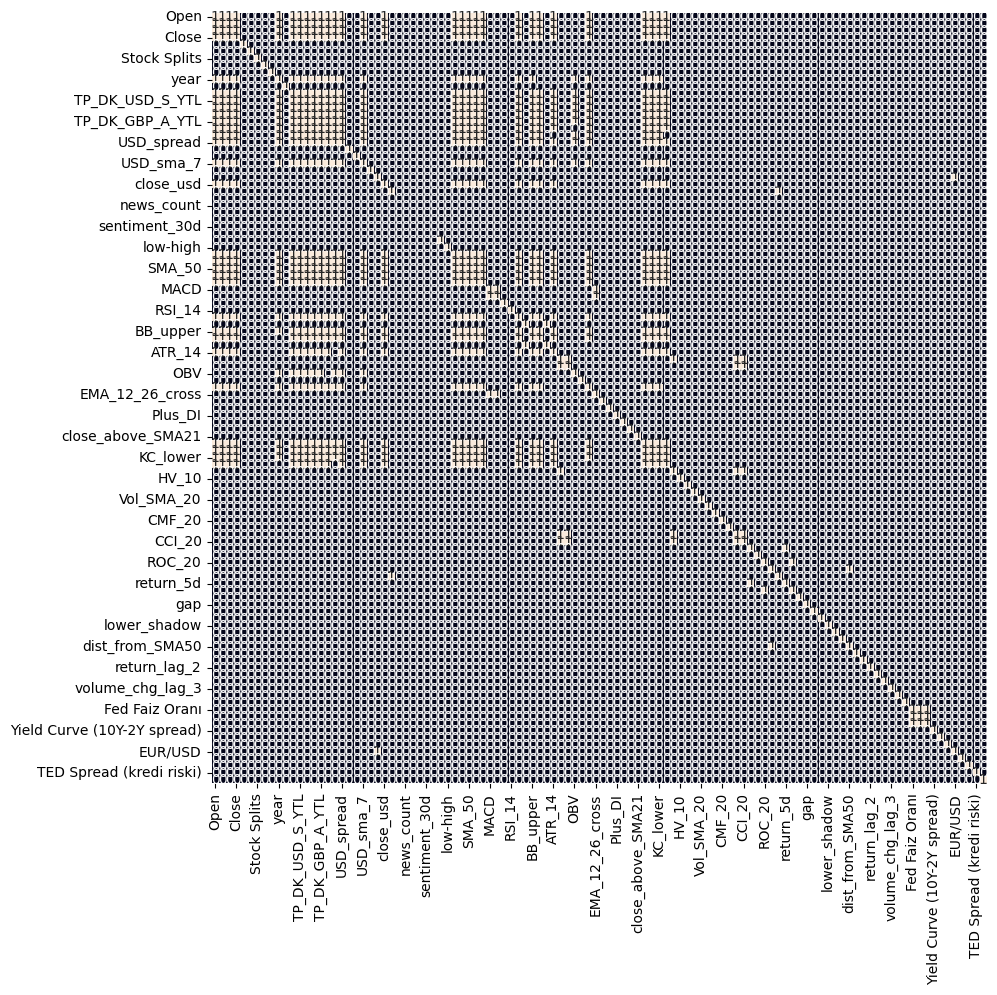

In [24]:
plt.figure(figsize=(10, 10)) 
sb.heatmap(df.corr() > 0.9, annot=True, cbar=False)
plt.show()

In [25]:
features = df[['open-close', 'low-high', 'is_quarter_end',
               'SMA_7', 'SMA_21', 'SMA_50',
               'MACD', 'MACD_signal', 'MACD_hist',
               'RSI_14',
               'BB_width', 'BB_upper', 'BB_lower',
               'ATR_14',
               'Stoch_K', 'Stoch_D',
               'OBV', 'Momentum_10', 'VWAP',
               # Sentiment
               'avg_sentiment', 'news_count', 'sentiment_7d',
               'sentiment_14d', 'sentiment_30d',

               # Makroekonomik (TCMB) # EVDS API
               'USD_change', 'USD_change_5d',
               'USD_sma_7', 
               'close_usd', 'close_usd_change',

               "TP_DK_USD_S_YTL", 'TP_DK_USD_A_YTL', 
               "USD_spread", "USD_volatility", "EUR_USD_ratio",

               #"TP_FG_J0", "TP_FG_J01", "TP_FG_J02",
               #"TP_AB_B1", "TP_AB_B3",

               # ABD bilgileri FRED
               'Fed Faiz Oranı', '10Y Tahvil Faizi', '2Y Tahvil Faizi',
               'Yield Curve (10Y-2Y spread)', 'VIX (volatilite endeksi)',
               'Ham Petrol Fiyatı', 'USD/CNY', 'Tüketici Güven Endeksi',
               'TED Spread (kredi riski)',
               ]]

target = df['target']

scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_valid, Y_train, Y_valid = train_test_split(
    features, 
    target, 
    test_size=0.1, 
    random_state=42, 
    stratify=target
)

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn import metrics
import gc


class TradingNN(nn.Module):
    """
    Tabular data için Residual Block'lu NN.

    Mimari:
        Input → Block1(256) → Block2(128) → Block3(64) → Output(1)

    Her blok:
        Linear → BatchNorm → GELU → Dropout + Residual bağlantı
    """

    def __init__(self, input_dim: int, dropout: float = 0.3):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.block1 = self._res_block(256, 256, dropout)
        self.block2 = self._res_block(256, 128, dropout)
        self.block3 = self._res_block(128, 64,  dropout)

        self.head = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

    @staticmethod
    def _res_block(in_dim, out_dim, dropout):
        block    = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        shortcut = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        return nn.ModuleList([block, shortcut])

    def _forward_res(self, x, res_block):
        block, shortcut = res_block
        return block(x) + shortcut(x)

    def forward(self, x):
        x = self.input_proj(x)
        x = self._forward_res(x, self.block1)
        x = self._forward_res(x, self.block2)
        x = self._forward_res(x, self.block3)
        return self.head(x).squeeze(1)



def train_trading_nn(
    X_train, Y_train,
    X_valid, Y_valid,
    epochs=100,
    batch_size=256,
    lr=1e-3,
    dropout=0.3,
    patience=15,
    device=None,
):
    # M1 Mac'te MPS segfault yapıyor, sadece CPU kullan
    device = "cpu"
    print(f"Device: {device}", flush=True)

    y_train_np = Y_train.values if hasattr(Y_train, 'values') else np.ascontiguousarray(Y_train)
    y_valid_np = Y_valid.values if hasattr(Y_valid, 'values') else np.ascontiguousarray(Y_valid)
    X_train_np = np.ascontiguousarray(X_train, dtype=np.float32)
    X_valid_np = np.ascontiguousarray(X_valid, dtype=np.float32)

    Xt = torch.from_numpy(X_train_np)
    Yt = torch.from_numpy(np.asarray(y_train_np, dtype=np.float32))
    Xv = torch.from_numpy(X_valid_np)
    Yv = torch.from_numpy(np.asarray(y_valid_np, dtype=np.float32))

    loader = DataLoader(
        TensorDataset(Xt, Yt),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=0,
    )

    model     = TradingNN(input_dim=X_train.shape[1], dropout=dropout)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Dengesiz sınıflar için ağırlıklı loss
    y_arr = np.asarray(y_train_np, dtype=np.float32)
    pos_weight = torch.tensor(
        float((y_arr == 0).sum()) / max(float((y_arr == 1).sum()), 1.0),
        dtype=torch.float32,
    )
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    history    = {"train_auc": [], "val_auc": [], "train_loss": []}
    best_auc   = 0.0
    best_state = None
    no_improve = 0

    print(f"\n{'Epoch':>6} | {'Loss':>8} | {'Train AUC':>9} | {'Val AUC':>8}", flush=True)
    print("-" * 42, flush=True)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            train_prob = torch.sigmoid(model(Xt)).numpy()
            val_prob   = torch.sigmoid(model(Xv)).numpy()

        train_auc = metrics.roc_auc_score(y_arr, train_prob)
        val_auc   = metrics.roc_auc_score(y_valid_np, val_prob)
        avg_loss  = total_loss / len(loader)

        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss"].append(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"{epoch:>6} | {avg_loss:>8.4f} | {train_auc:>9.4f} | {val_auc:>8.4f}", flush=True)

        if val_auc > best_auc:
            best_auc   = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n⏹  Early stopping @ epoch {epoch} | Best Val AUC: {best_auc:.4f}")
                break

    model.load_state_dict(best_state)
    gc.collect()
    print(f"\n✓ Tamamlandı. Best Val AUC: {best_auc:.4f}")
    return model, history


def evaluate(model, X, Y, label="", device=None):
    model.eval()
    Xt = torch.from_numpy(np.ascontiguousarray(X, dtype=np.float32))
    with torch.no_grad():
        prob = torch.sigmoid(model(Xt)).numpy()

    pred = (prob >= 0.5).astype(int)
    Y_np = Y.values if hasattr(Y, 'values') else np.array(Y)

    print(f"\n── {label} ──")
    print(f"AUC      : {metrics.roc_auc_score(Y_np, prob):.4f}")
    print(f"Accuracy : {metrics.accuracy_score(Y_np, pred):.4f}")
    print(metrics.classification_report(Y_np, pred, target_names=["Down", "Up"]))
    return prob

class TradingNNWrapper:
    """sklearn-compatible wrapper — predict_proba döndürür."""
    
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.model  = None

    def fit(self, X, y, X_val=None, y_val=None):
        self.model, self.history = train_trading_nn(
            X, y, X_val, y_val, **self.kwargs
        )
        return self

    def predict_proba(self, X):
        self.model.eval()
        Xt = torch.from_numpy(np.ascontiguousarray(X, dtype=np.float32))
        with torch.no_grad():
            prob = torch.sigmoid(self.model(Xt)).numpy()
        return np.column_stack([1 - prob, prob])   # shape: (n, 2)

    def __repr__(self):
        return "TradingNN(residual)"

In [27]:
FEATURE_GROUPS = {
    "technical": [
        'open-close', 'low-high', 'is_quarter_end',
        'SMA_7', 'SMA_21', 'SMA_50',
        'MACD', 'MACD_signal', 'MACD_hist',
        'RSI_14', 'BB_width', 'BB_upper', 'BB_lower',
        'ATR_14', 'Stoch_K', 'Stoch_D',
        'OBV', 'Momentum_10', 'VWAP',
    ],
    "technical_extra": [
        # Trend
        'EMA_12_26_cross', 'SMA_7_21_cross',
        'ADX_14', 'Plus_DI', 'Minus_DI',
        'close_above_SMA50', 'close_above_SMA21',
        # Volatilite
        'KC_width', 'BB_pctB', 'HV_10', 'HV_30', 'ATR_pct',
        # Volume
        'Vol_ratio', 'MFI_14', 'CMF_20', 'Force_13',
        # Momentum
        'Williams_R', 'CCI_20', 'ROC_5', 'ROC_10', 'ROC_20', 'TSI',
        # Fiyat yapısı
        'return_1d', 'return_5d', 'return_20d',
        'close_position', 'gap', 'body_ratio',
        'upper_shadow', 'lower_shadow',
        'pct_from_52w_high', 'pct_from_52w_low',
        'dist_from_SMA50',
        # Lag
        'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5',
        'volume_chg_lag_1', 'volume_chg_lag_2', 'volume_chg_lag_3', 'volume_chg_lag_5',
    ],
    "sentiment": [
        'avg_sentiment', 'news_count', 'sentiment_7d',
        'sentiment_14d', 'sentiment_30d',
    ],
    "macro_fx": [
        'USD_change', 'USD_change_5d', 'USD_sma_7',
        'close_usd', 'close_usd_change',
        'TP_DK_USD_S_YTL', 'TP_DK_USD_A_YTL',
        'USD_spread', 'USD_volatility', 'EUR_USD_ratio',
    ],
    "fred": [
        'Fed Faiz Oranı', '10Y Tahvil Faizi', '2Y Tahvil Faizi',
        'Yield Curve (10Y-2Y spread)', 'VIX (volatilite endeksi)',
        'Ham Petrol Fiyatı', 'USD/CNY', 'Tüketici Güven Endeksi',
        'TED Spread (kredi riski)',
    ],
}

COMBINATIONS = {
    "only_technical":             ["technical"],
    "tech+tech_extra":            ["technical", "technical_extra"],
    "technical+sentiment":        ["technical", "sentiment"],
    "technical+macro_fx":         ["technical", "macro_fx"],
    "technical+fred":             ["technical", "fred"],
    "tech+extra+sentiment":       ["technical", "technical_extra", "sentiment"],
    "tech+macro+fred":            ["technical", "macro_fx", "fred"],
    "technical+sentiment+macro":  ["technical", "sentiment", "macro_fx"],
    "all":                        ["technical", "sentiment", "macro_fx", "fred"],
    "all_extended":               ["technical", "technical_extra", "sentiment", "macro_fx", "fred"],
}

In [28]:
def run_nn_experiments(
    df: pd.DataFrame,
    target_col: str = "target",
    combinations: dict = COMBINATIONS,
    nn_kwargs: dict = None,
    test_size: float = 0.1,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Farklı feature kombinasyonlarını TradingNNWrapper ile dener.

    Returns
    -------
    pd.DataFrame — her kombinasyon için Train/Val AUC sonuçları
    """
    if nn_kwargs is None:
        nn_kwargs = dict(epochs=50, batch_size=128, lr=1e-3, patience=15)

    results = []

    for combo_name, groups in combinations.items():
        # İlgili feature sütunlarını al (df'de yoksa atla)
        cols = []
        for g in groups:
            for c in FEATURE_GROUPS[g]:
                if c in df.columns:
                    cols.append(c)
                else:
                    print(f"  ⚠️  Eksik sütun: {c} ({combo_name})")

        if not cols:
            print(f"  ❌ {combo_name}: hiç sütun bulunamadı, atlanıyor.")
            continue

        print(f"\n{'='*55}")
        print(f"▶  {combo_name}  ({len(cols)} feature)")
        print(f"{'='*55}")

        X = df[cols].values.astype(np.float64)
        y = df[target_col].values

        # inf değerleri temizle (teknik indikatörlerde oluşabiliyor)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

        scaler = StandardScaler()
        X = scaler.fit_transform(X)

        X_train, X_valid, Y_train, Y_valid = train_test_split(
            X, y,
            test_size=test_size,
            random_state=random_state,
            stratify=y,
        )

        try:
            wrapper = TradingNNWrapper(**nn_kwargs)
            wrapper.fit(X_train, Y_train, X_val=X_valid, y_val=Y_valid)

            train_auc = metrics.roc_auc_score(Y_train, wrapper.predict_proba(X_train)[:, 1])
            val_auc   = metrics.roc_auc_score(Y_valid, wrapper.predict_proba(X_valid)[:, 1])

            print(f"  Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}")

            results.append({
                "combination":  combo_name,
                "n_features":   len(cols),
                "train_auc":    round(train_auc, 4),
                "val_auc":      round(val_auc, 4),
            })
        except Exception as e:
            print(f"  ❌ Hata: {e}")
            results.append({
                "combination": combo_name,
                "n_features":  len(cols),
                "train_auc":   None,
                "val_auc":     None,
            })

    result_df = pd.DataFrame(results).sort_values("val_auc", ascending=False)
    print(f"\n{'='*55}")
    print("📊 SONUÇLAR (Val AUC'ye göre sıralı):")
    print(result_df.to_string(index=False))
    return result_df


In [29]:
results = run_nn_experiments(df, nn_kwargs=dict(epochs=150, batch_size=128, lr=1e-3, patience=50, device="cpu"))


▶  only_technical  (19 feature)
Device: cpu

 Epoch |     Loss | Train AUC |  Val AUC
------------------------------------------
     1 |   0.7073 |    0.5668 |   0.4970
    10 |   0.6815 |    0.6300 |   0.4827
    20 |   0.6723 |    0.6639 |   0.4755
    30 |   0.6594 |    0.7020 |   0.5072
    40 |   0.6389 |    0.7294 |   0.5152
    50 |   0.6248 |    0.7567 |   0.4960

⏹  Early stopping @ epoch 54 | Best Val AUC: 0.5509

✓ Tamamlandı. Best Val AUC: 0.5509
  Train AUC: 0.5822 | Val AUC: 0.5509

▶  tech+tech_extra  (60 feature)
Device: cpu

 Epoch |     Loss | Train AUC |  Val AUC
------------------------------------------
     1 |   0.7040 |    0.5771 |   0.5119
    10 |   0.6339 |    0.7582 |   0.5357
    20 |   0.5604 |    0.8489 |   0.5068
    30 |   0.4786 |    0.9355 |   0.4763
    40 |   0.3983 |    0.9707 |   0.4671
    50 |   0.3520 |    0.9885 |   0.4345
    60 |   0.3214 |    0.9955 |   0.4363

⏹  Early stopping @ epoch 62 | Best Val AUC: 0.5414

✓ Tamamlandı. Best Val AU